# Lecture 8d — Complexity, and does any of it beat equal weights?

**AI-powered Investment and Risk Management (25882) · Vitali Alexeev · UTS Business School**

Two halves, and they pull against each other.

**Part A** shows a result that should not be true. We take a model with more
parameters than observations — far more — and it works. The classical warning about
over-parameterisation turns out to be misplaced, and the place it goes wrong is
specific and locatable.

**Part B** takes trees, boosting and neural networks to a real prediction problem:
timing the 158 anomalies from Lecture 8b. Every model finds genuine predictive
signal. Then we compare against the least sophisticated benchmark available and see
what that signal is worth.

The two halves together are the argument of the lecture in miniature: **complexity
can help, and it is still not the binding constraint.**

*Runtime: 4–8 minutes.*

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go

import airm8
from airm8 import *

pd.set_option("display.precision", 4)
RNG = lambda seed: np.random.default_rng(seed)

---
# Part A — More parameters than observations

## A1. The rule you were taught

Parameters must be fewer than observations. Past that point the model interpolates
the training data, fits the noise exactly, and generalises terribly.

Lecture 8a supported this: with $p = 100$ and $n = 200$, OLS posted a *negative*
out-of-sample $R^2$. Everything in Lecture 8's Section 3 was built on managing the
ratio of parameters to data.

Now we push the ratio to 100 and see what happens.

## A2. The experiment

Take $T = 120$ monthly observations and five raw predictors. Expand them into $P$
**random nonlinear features** — random projections passed through a cosine — and
sweep $P$ from 12 (well under $T$) to 12,000 (a hundred times $T$).

At each complexity we fit ridge at several penalty strengths $z$, including one so
small it is effectively no penalty at all.

<details>
<summary><b>The maths: random features, and what happens when $P > T$</b> (click to expand)</summary>

Draw $W$ and $b$ at random and form $Z = \sqrt{2/P}\cos(XW + b)$. As $P$ grows,
these features span an increasingly rich class of smooth functions — this is a
cheap approximation to a kernel method.

Ridge solves $\hat\beta = (Z'Z + zP\,I)^{-1}Z'y$. When $P > T$ the matrix $Z'Z$
is **singular**: there are infinitely many coefficient vectors that fit the
training data exactly. The penalty selects among them, and as $z \to 0$ the
solution converges to the **minimum-norm interpolator** — of all the perfect
fits, the smallest.

That is the key. Extra parameters beyond the interpolation point add no fitting
capacity, because there is none left to add. What they add is *more interpolating
solutions to choose from*, letting the minimum-norm rule pick a smoother one.

Computationally, when $P > T$ we solve the equivalent $T \times T$ dual problem
$\hat\beta = Z'(ZZ' + zP\,I)^{-1}y$, which is both faster and better conditioned.

</details>

In [2]:
# Replications across 24 complexity levels and 5 shrinkage levels.
# 12 replications keeps this under two minutes. Raise to 30 for smoother
# curves if you have the time -- the shape does not change.
N_REPS = 12
sweep = pd.concat([
    complexity_sweep(RNG(7000 + rep), T=120, d=5, n_test=4_000)
    for rep in range(N_REPS)
], ignore_index=True)

print(f"{len(sweep):,} rows | complexity from c={sweep.c.min():.2f} "
      f"to c={sweep.c.max():.0f} | shrinkage levels {[float(z) for z in sorted(sweep.z.unique())]}")

1,440 rows | complexity from c=0.10 to c=100 | shrinkage levels [1e-06, 0.01, 0.1, 1.0, 10.0]


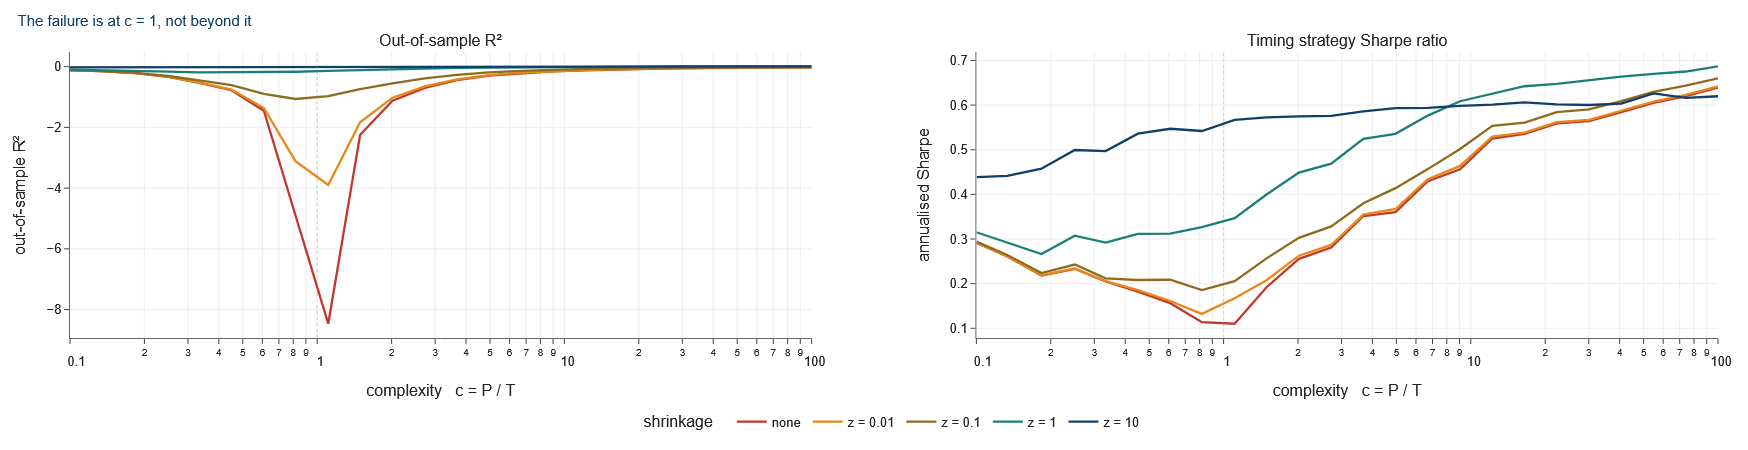

In [3]:
plot_complexity(sweep, title="The failure is at c = 1, not beyond it")

In [4]:
med = sweep.groupby(["z", "c"])[["oos_r2", "timing_sharpe"]].median().reset_index()

def at(z, c, col):
    s = med[med.z == z]
    return s.iloc[(s.c - c).abs().argmin()][col]

print("Ridgeless (no shrinkage):")
for c in [0.1, 0.5, 1.0, 10, 100]:
    print(f"   c = {c:5.1f}   R² {at(1e-6, c, 'oos_r2'): 8.3f}"
          f"   Sharpe {at(1e-6, c, 'timing_sharpe'):.3f}")
print("\nWith shrinkage (z = 1):")
for c in [0.1, 0.5, 1.0, 10, 100]:
    print(f"   c = {c:5.1f}   R² {at(1.0, c, 'oos_r2'): 8.3f}"
          f"   Sharpe {at(1.0, c, 'timing_sharpe'):.3f}")

Ridgeless (no shrinkage):
   c =   0.1   R²   -0.119   Sharpe 0.292
   c =   0.5   R²   -0.776   Sharpe 0.182
   c =   1.0   R²   -8.466   Sharpe 0.110
   c =  10.0   R²   -0.151   Sharpe 0.456
   c = 100.0   R²   -0.026   Sharpe 0.639

With shrinkage (z = 1):
   c =   0.1   R²   -0.097   Sharpe 0.315
   c =   0.5   R²   -0.187   Sharpe 0.311
   c =   1.0   R²   -0.137   Sharpe 0.347
   c =  10.0   R²   -0.010   Sharpe 0.609
   c = 100.0   R²    0.012   Sharpe 0.687


## A3. Three things in that output

**The blow-up is at $c = 1$, not beyond it.** Without shrinkage, out-of-sample $R^2$
collapses to around $-8$ exactly where parameters equal observations — and then
*recovers* as complexity keeps growing. This is the **double descent** curve. The
region the classical rule warned you about is the region where the rule is right; the
region it forbids is fine.

**Shrinkage removes the pathology entirely.** At $z = 1$ there is no collapse at all
and performance climbs monotonically in complexity. This is why "complexity is a
virtue" is a compressed statement of "complexity *plus appropriate shrinkage* is a
virtue". The second clause is not optional.

**$R^2$ and economic value disagree.** At the highest complexity with no shrinkage,
$R^2$ is still slightly negative — apparent failure — while the timing strategy earns
a Sharpe ratio near 0.6. A forecast can be badly *scaled* and still be correctly
*ordered*, and it is the ordering that pays.

That last point is Kelly, Malamud and Zhou's (2024) central empirical claim, and you
have just reproduced its shape from scratch.

---
# Part B — Trees, boosting and networks on a real panel

## B1. The problem

We have 158 anomaly long-short portfolios from Lecture 8b, monthly, 1975–2024. Can we
predict which of them will do well next month?

This is **factor timing**, and Section 6 of the lecture warned that it compounds every
estimation problem in the subject. Let us find out.

Features for signal $i$ at month $t$ use only that signal's own history strictly
before $t$, plus its rank within the cross-section. Nothing from month $t$ enters, and
no other signal's month-$t$ return enters either.

In [5]:
zoo = load_open_source_zoo()
panel = build_timing_panel(zoo)
features = timing_feature_names(panel)

print(f"{len(panel):,} signal-months | {len(features)} features "
      f"| {panel.date.nunique()} months | {panel.signal.nunique()} signals")
print(f"Features: {', '.join(features)}")
panel.head()

89,112 signal-months | 9 features | 564 months | 158 signals
Features: ret_1m, ret_3m, ret_12m, ret_36m, vol_12m, vol_36m, ret_1m_rank, ret_12m_rank, vol_12m_rank


,date,ret_1m,ret_3m,ret_12m,ret_36m,vol_12m,vol_36m,target,signal,ret_1m_rank,ret_12m_rank,vol_12m_rank
0,1978-01-31,-0.0079,-0.0024,0.0106,0.0118,0.0227,0.0416,0.0553,AM,0.1899,0.7152,0.7405
1,1978-01-31,0.0194,0.0085,0.0088,0.0086,0.0118,0.0196,0.0164,AbnormalAccruals,0.9304,0.6582,0.3671
2,1978-01-31,0.0123,0.0134,0.0056,0.0032,0.0105,0.0148,0.0097,Accruals,0.8354,0.5000,0.3101
3,1978-01-31,-0.0218,-0.0029,0.0108,0.0213,0.0294,0.0647,0.0753,AccrualsBM,0.0190,0.7468,0.8734
4,1978-01-31,-0.0155,0.0031,0.0063,0.0114,0.0178,0.0378,0.0360,AdExp,0.0506,0.5380,0.6076


### Splitting a panel without leaking

Two rules, both from Lecture 8a and both violated by the 2024 version of this lab.

1. **Group by date.** An entire cross-section must move together. If some signals
   from month $t$ are in training and others in testing, contemporaneous information
   leaks across the split.
2. **Fit every transformation inside the pipeline** so scalers are refitted on each
   training fold.

Our target is a one-month return, so successive observations do not share an outcome
window and purging is not strictly required here. It becomes essential the moment you
move to overlapping multi-month targets — which is exactly where the 2024 notebook
came unstuck.

In [6]:
cut = panel.date.quantile(0.6)
train_mask = (panel.date <= cut).values
test_mask = (panel.date > cut).values

X = panel[features].values
y = panel["target"].values
dates = panel["date"].values

print(f"Train: {panel.date.min():%Y-%m} to {cut:%Y-%m}  "
      f"({train_mask.sum():,} rows)")
print(f"Test : {cut:%Y-%m} to {panel.date.max():%Y-%m}  "
      f"({test_mask.sum():,} rows)")

# The splitter used for tuning inside the training window.
cv = PurgedGroupTimeSeriesSplit(n_splits=4, purge=1)
for k, (a, b) in enumerate(cv.split(X[train_mask], y[train_mask],
                                    dates[train_mask])):
    print(f"   fold {k}: train {len(a):>6,} rows | validate {len(b):>6,} rows")

Train: 1978-01 to 2006-03  (53,562 rows)
Test : 2006-03 to 2024-12  (35,550 rows)
   fold 0: train 10,586 rows | validate 10,586 rows
   fold 1: train 21,172 rows | validate 10,586 rows
   fold 2: train 31,758 rows | validate 10,586 rows
   fold 3: train 42,344 rows | validate 10,586 rows


## B2. Establish the benchmark first

Before fitting anything, write down what we have to beat. The least sophisticated
strategy available: **hold all 158 signals in equal weight and never trade.**

In [7]:
test = panel.loc[test_mask].copy()
benchmark_returns = test.groupby("date")["target"].mean()
BENCHMARK = annualised_sharpe(benchmark_returns)

print(f"BENCHMARK — equal weight, no timing, no model")
print(f"   annualised Sharpe   {BENCHMARK:.2f}")
print(f"   annualised return   {benchmark_returns.mean() * 12:.2%}")

BENCHMARK — equal weight, no timing, no model
   annualised Sharpe   1.40
   annualised return   3.23%


Sharpe 1.4 from a strategy with no parameters, no estimation and no turnover. That is
the number every model below has to justify itself against.

In [8]:
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Ridge": Pipeline([("scale", StandardScaler()),
                       ("model", RidgeCV(alphas=np.logspace(-2, 5, 60)))]),
    "Random forest": RandomForestRegressor(
        n_estimators=200, min_samples_leaf=200, max_features="sqrt",
        random_state=0, n_jobs=-1),
    "Grad. boosting": HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.03, max_leaf_nodes=8,
        early_stopping=True, random_state=0),
    "Neural net (32,16)": Pipeline([
        ("scale", StandardScaler()),
        ("model", MLPRegressor(hidden_layer_sizes=(32, 16), alpha=1.0,
                               max_iter=400, random_state=0))]),
}

bench_mean = y[train_mask].mean()
rows, preds = [], {}

for name, est in models.items():
    est.fit(X[train_mask], y[train_mask])
    p = est.predict(X[test_mask])
    preds[name] = p

    frame = test.assign(pred=p)
    ic, ic_se = rank_ic(frame)

    def long_short(x):
        k = max(len(x) // 5, 1)
        o = x.sort_values("pred")
        return o.target.iloc[-k:].mean() - o.target.iloc[:k].mean()

    ls = frame.groupby("date").apply(long_short, include_groups=False)
    rows.append(dict(model=name,
                     oos_r2=oos_r2(y[test_mask], p, bench_mean),
                     rank_ic=ic, ic_t=ic / ic_se,
                     ls_sharpe=annualised_sharpe(ls)))

results = pd.DataFrame(rows)
print(results.to_string(index=False))

             model  oos_r2  rank_ic   ic_t  ls_sharpe
             Ridge  0.0047   0.1069 4.8121     0.7435
     Random forest  0.0062   0.0987 4.4413     0.6844
    Grad. boosting -0.0041   0.1014 4.4980     0.7499
Neural net (32,16)  0.0028   0.0999 4.2061     0.7130


## B3. Reading that table honestly

**The models do find something.** Rank information coefficients near 0.10, with
$t$-statistics above 4, are not noise. There is real predictable structure in which
anomalies do well next month, and all four model families find roughly the same
amount of it.

**The $R^2$ values are tiny, and one is negative.** Note which model has the negative
$R^2$ — and note that it is not the worst performer on the long-short Sharpe. This is
the Part A divergence appearing on real data: a forecast can be poorly scaled and
correctly ordered.

**Every model is beaten by equal weights.** The long-short timing portfolios earn
Sharpe ratios around 0.7. The benchmark, which required no estimation at all, earns
about 1.4.

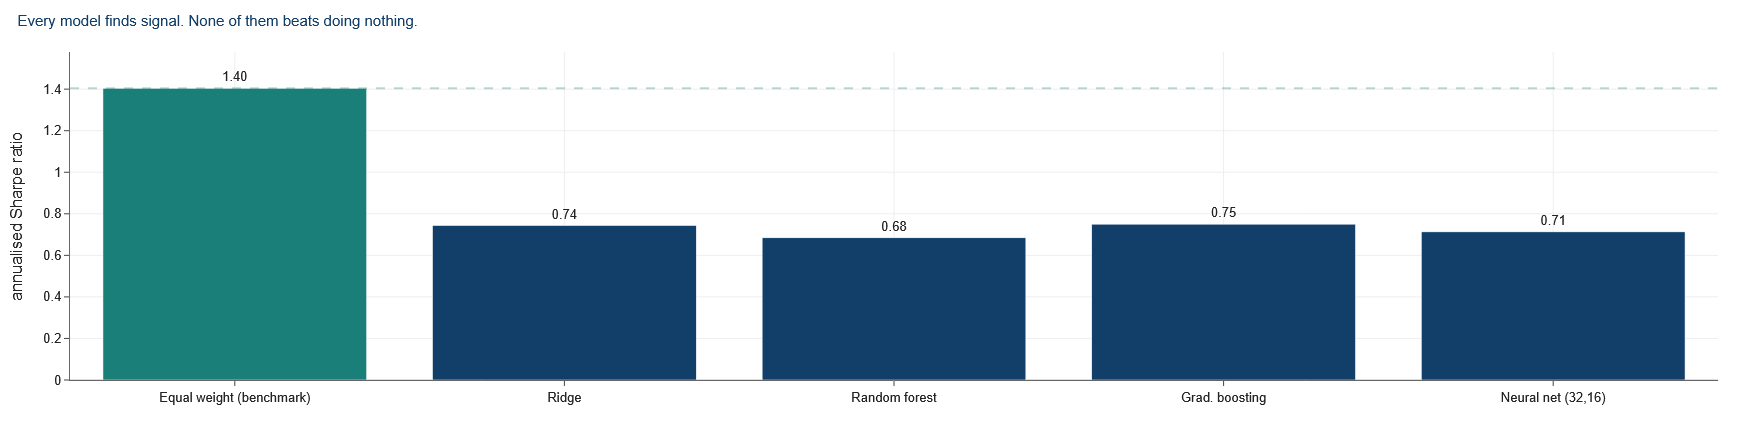

In [9]:
comparison = (results[["model", "ls_sharpe"]]
              .rename(columns={"ls_sharpe": "sharpe"}))
comparison = pd.concat([
    pd.DataFrame([{"model": "Equal weight (benchmark)", "sharpe": BENCHMARK}]),
    comparison], ignore_index=True)

fig = go.Figure(go.Bar(
    x=comparison.model, y=comparison.sharpe,
    marker_color=[TEAL] + [NAVY] * len(results),
    text=[f"{v:.2f}" for v in comparison.sharpe],
    textposition="outside", cliponaxis=False))
fig.add_hline(y=BENCHMARK, line=dict(color=TEAL, width=2, dash="dash"))
fig.update_yaxes(title="annualised Sharpe ratio")
airm_layout(fig, "Every model finds signal. None of them beats doing nothing.",
            height=440)

Before concluding too much, notice that this is not a like-for-like comparison. The
long-short timing portfolio is neutral to the average anomaly; the benchmark is fully
exposed to it. They are different bets with different exposures.

The fair question is not *"does timing beat equal weights"* but **"does timing improve
equal weights"**. That is what a practitioner would actually do: hold the static
allocation and tilt it.

---
# Part C — Does timing improve the static allocation?

Take the equal-weighted portfolio and tilt it towards the signals the model ranks
highly. A tilt of zero recovers the benchmark exactly. Weights are rescaled to
constant gross exposure at every date, so nothing here is leverage in disguise.

In [10]:
best_model = results.loc[results.ls_sharpe.idxmax(), "model"]
frame = test.assign(pred=preds[best_model])
frame["prank"] = frame.groupby("date")["pred"].rank(pct=True)

rows = []
for tilt in [0.0, 0.25, 0.5, 1.0, 2.0, 3.0]:
    r = tilted_portfolio(frame, tilt)
    rows.append(dict(tilt=tilt,
                     ann_return=r.mean() * 12,
                     ann_vol=r.std() * np.sqrt(12),
                     sharpe=annualised_sharpe(r)))

overlay = pd.DataFrame(rows)
print(f"Timing overlay using {best_model}:\n")
print(overlay.to_string(index=False))

Timing overlay using Grad. boosting:

 tilt  ann_return  ann_vol  sharpe
 0.00      0.0323   0.0230  1.4041
 0.25      0.0384   0.0276  1.3904
 0.50      0.0446   0.0335  1.3313
 1.00      0.0568   0.0468  1.2127
 2.00      0.0653   0.0611  1.0687
 3.00      0.0639   0.0642  0.9951


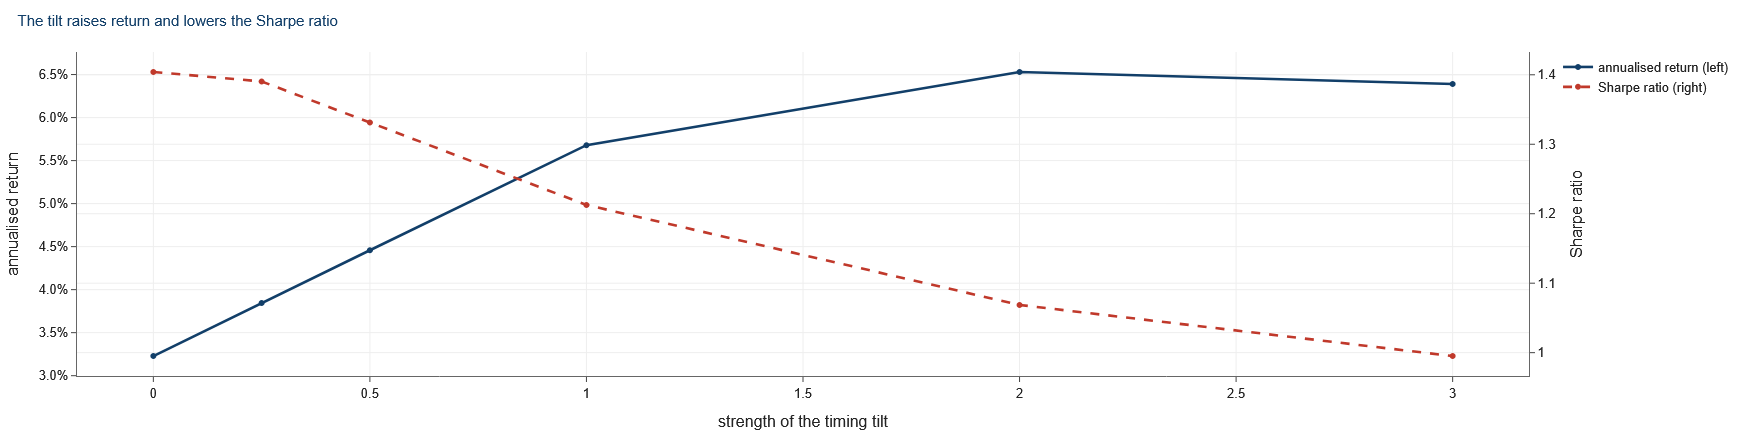

In [11]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=overlay.tilt, y=overlay.ann_return, mode="lines+markers",
                         name="annualised return (left)",
                         line=dict(color=NAVY, width=2.6), yaxis="y"))
fig.add_trace(go.Scatter(x=overlay.tilt, y=overlay.sharpe, mode="lines+markers",
                         name="Sharpe ratio (right)",
                         line=dict(color=RED, width=2.6, dash="dash"), yaxis="y2"))
fig.update_layout(
    yaxis=dict(title="annualised return", tickformat=".1%"),
    yaxis2=dict(title="Sharpe ratio", overlaying="y", side="right",
                showgrid=False))
fig.update_xaxes(title="strength of the timing tilt")
airm_layout(fig, "The tilt raises return and lowers the Sharpe ratio", height=440)

## The result

**Return rises, then stalls. Risk-adjusted return falls throughout.** Tilting roughly
doubles the annualised return before it peaks and turns back down, which confirms the
forecast carries real information — a worthless signal could not lift returns at all.
But volatility rises faster than return at every step, so the Sharpe ratio declines
monotonically from the benchmark, and it never recovers.

So the honest summary of Part B and Part C together:

> The models detect genuine structure in anomaly returns. Acting on that structure
> makes the portfolio worse on a risk-adjusted basis, before we have paid a single
> basis point of transaction costs.

And costs would fall hardest here. The benchmark has essentially no turnover; every
tilted variant trades every month across 158 portfolios.

This is why the lecture treats factor timing sceptically, and why "the model found a
statistically significant signal" is not the end of an argument. It is the beginning
of one.

### Putting Part A and Part C side by side

Part A showed that a model with a hundred times more parameters than observations can
outperform a parsimonious one. Part C showed that four different models, all finding
statistically strong signal, cannot improve on an equal-weighted portfolio.

Both are true, and the tension between them is the state of the field:

- The **statistical** constraint on complexity is much weaker than the textbooks
  claim. Given shrinkage, you can afford far more parameters than you were taught.
- The **economic** constraint has not moved. Risk-adjusted improvement over a simple
  benchmark remains extremely hard, and it gets harder once costs are counted.

Advances in method have relaxed the first constraint considerably. They have done
very little about the second.

---
## Exercises

### Core

**C1.** In Part A, find the complexity $c$ at which the ridgeless model's
out-of-sample $R^2$ is worst. Does that point move if you change $T$ from 120 to 240?
What does your answer imply about *why* the failure happens where it does?

**C2.** Part B splits at the 60th percentile of dates. Move the split to 1990 and to
2010. Does the ranking of models change? Does any of them ever beat the benchmark?

**C3.** The neural network uses `alpha=1.0`, a fairly strong penalty. Set it to
`1e-6` and refit. Relate what happens to the ridgeless curve in Part A.

**C4.** Add a transaction cost of 10 basis points per unit of turnover to the Part C
overlay. At what tilt does the strategy stop beating a term deposit?

### Stretch

**S1.** Replace the random Fourier features in Part A with polynomial features of the
same dimension. Does double descent still appear? What does that tell you about how
much the specific feature map matters?

**S2.** Part C tilts using one model. Average the forecasts of all four and repeat.
Does the ensemble improve the Sharpe ratio, and if so where does the improvement come
from — better ordering, or lower forecast variance?

**S3.** Our features are all built from a signal's own past returns. Add features
describing the *state of the market* — for example the cross-sectional dispersion of
anomaly returns, or their average correlation over the trailing year. Does conditioning
on the environment rather than on past performance change the conclusion?

**S4.** Apply the Part A machinery to the Part B panel: build $P$ random features from
the nine timing predictors and sweep $P/T$. Does the virtue of complexity survive
contact with real data? Report both $R^2$ and the tilted-portfolio Sharpe, and say
which you would put in a report.

**S5.** The benchmark holds all 158 signals. Some are far more expensive to trade than
others. Using turnover as a proxy for cost, construct a cost-aware benchmark that
drops the most expensive quartile. Is *that* harder to beat, or easier?

---

### Where this sits in the subject

Lecture 8 ends here. Lectures 10 and 11 take the governance question directly: when a
model is a transformer with tens of thousands of parameters, what do you owe a
regulator, a risk committee, and a client — and which of the diagnostics you have used
across these four notebooks would actually survive an audit?